# Treino com Amostras da Base de Dados

Este notebook treina o modelo AquaSense usando **dados reais** da base de dados MySQL.

**Vantagens:**
- Dados reais do aquário
- Modelo aprende padrões reais
- Melhor generalização para produção

**Requisitos:**
- MySQL/MariaDB a correr (No nosso caso XAMPP porta 3309)
- Base de dados `esp32_data` com tabela `leituras_sensores`
- Sensores: `turbidity`, `pH`, `temperature`

In [1]:
import sys
sys.path.insert(0, '..')

import numpy as np
import torch
import matplotlib.pyplot as plt
import mysql.connector
from datetime import datetime

from src.config import (
    DB_CONFIG, RANDOM_SEED, DEVICE, MODEL_PATH, SCALER_PATH, METRICS_PATH,
    get_expected_adjustment, get_expected_tpa, get_expected_feeding
)
from src.data_loader import StandardScaler, create_dataloaders
from src.model import AquaSenseNet

print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"\nConfiguração BD:")
print(f"  Host: {DB_CONFIG['host']}:{DB_CONFIG['port']}")
print(f"  Database: {DB_CONFIG['database']}")

Device: cpu
PyTorch: 2.10.0+cpu

Configuração BD:
  Host: 127.0.0.1:3309
  Database: esp32_data


## 1. Configuração

In [2]:
# Hiperparâmetros
TEST_SIZE = 0.2        # 20% para teste
BATCH_SIZE = 32
EPOCHS = 500
LEARNING_RATE = 0.001
PATIENCE = 50          # Early stopping
MIN_SAMPLES = 100      # Mínimo de amostras da BD

print(f"Configuração:")
print(f"  Treino/Teste: {100-TEST_SIZE*100:.0f}%/{TEST_SIZE*100:.0f}%")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Épocas máx: {EPOCHS}")
print(f"  Early stopping: {PATIENCE} épocas")
print(f"  Mínimo amostras BD: {MIN_SAMPLES}")

Configuração:
  Treino/Teste: 80%/20%
  Batch size: 32
  Épocas máx: 500
  Early stopping: 50 épocas
  Mínimo amostras BD: 100


## 2. Carregar Dados da BD

In [3]:
def load_data_from_db():
    """Carrega dados reais da base de dados MySQL."""
    conn = mysql.connector.connect(**DB_CONFIG)
    cursor = conn.cursor(dictionary=True)
    
    # Query para obter leituras agrupadas por janela temporal
    query = """
    SELECT 
        DATE_FORMAT(data_hora, '%Y-%m-%d %H:%i') as time_window,
        MAX(CASE WHEN tipo_sensor = 'turbidity' THEN valor END) as turbidez,
        MAX(CASE WHEN tipo_sensor = 'pH' THEN valor END) as ph,
        MAX(CASE WHEN tipo_sensor = 'temperature' THEN valor END) as temperatura
    FROM leituras_sensores
    WHERE tipo_sensor IN ('turbidity', 'pH', 'temperature')
    GROUP BY time_window
    HAVING turbidez IS NOT NULL 
       AND ph IS NOT NULL 
       AND temperatura IS NOT NULL
    ORDER BY time_window DESC
    LIMIT 50000
    """
    
    cursor.execute(query)
    rows = cursor.fetchall()
    cursor.close()
    conn.close()
    
    return rows

# Carregar dados
print("Conectando à base de dados...")
rows = load_data_from_db()
print(f"✓ {len(rows)} amostras carregadas da BD")

Conectando à base de dados...
✓ 19875 amostras carregadas da BD


In [4]:
# Verificar período dos dados
if rows:
    first_date = rows[-1]['time_window']
    last_date = rows[0]['time_window']
    print(f"\nPeríodo dos dados:")
    print(f"  Início: {first_date}")
    print(f"  Fim: {last_date}")
    
    # Exemplos
    print(f"\nExemplos de dados:")
    for row in rows[:5]:
        print(f"  {row['time_window']}: Turb={float(row['turbidez']):.1f}%, "
              f"pH={float(row['ph']):.2f}, Temp={float(row['temperatura']):.1f}°C")


Período dos dados:
  Início: 2025-10-28 19:35
  Fim: 2026-02-04 17:35

Exemplos de dados:
  2026-02-04 17:35: Turb=0.0%, pH=6.98, Temp=25.2°C
  2026-02-04 17:34: Turb=0.0%, pH=6.91, Temp=25.2°C
  2026-02-04 17:26: Turb=0.0%, pH=7.05, Temp=25.2°C
  2026-02-04 17:25: Turb=0.0%, pH=7.05, Temp=25.2°C
  2026-02-04 17:24: Turb=0.0%, pH=7.14, Temp=25.2°C


In [5]:
# Converter para arrays numpy
turbidity = np.array([float(r['turbidez']) for r in rows], dtype=np.float32)
ph = np.array([float(r['ph']) for r in rows], dtype=np.float32)
temperature = np.array([float(r['temperatura']) for r in rows], dtype=np.float32)

X = np.column_stack([turbidity, ph, temperature])

print(f"\nEstatísticas dos dados:")
print(f"  Turbidez: min={turbidity.min():.1f}, max={turbidity.max():.1f}, mean={turbidity.mean():.1f}")
print(f"  pH: min={ph.min():.2f}, max={ph.max():.2f}, mean={ph.mean():.2f}")
print(f"  Temperatura: min={temperature.min():.1f}, max={temperature.max():.1f}, mean={temperature.mean():.1f}")


Estatísticas dos dados:
  Turbidez: min=0.0, max=100.0, mean=12.2
  pH: min=2.15, max=14.93, mean=7.00
  Temperatura: min=12.1, max=85.0, mean=23.8


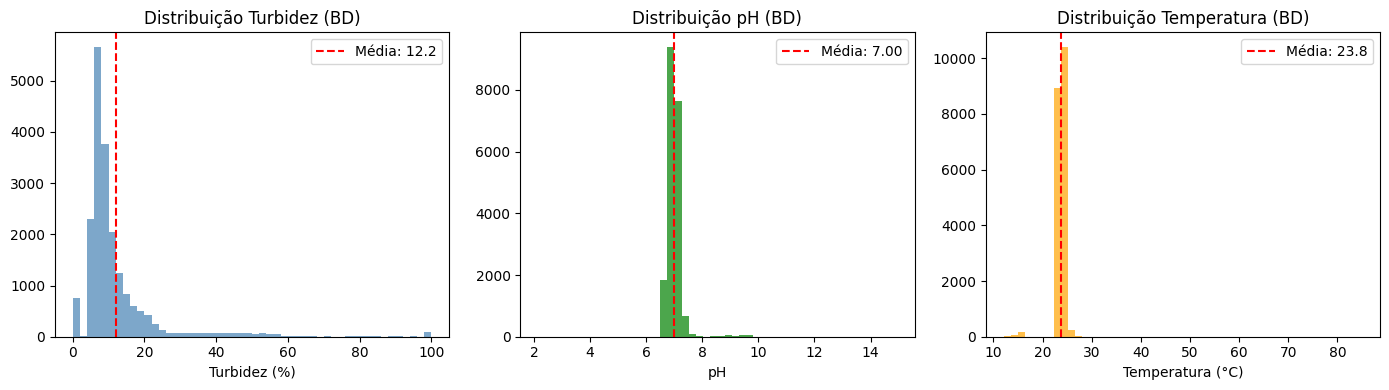

In [6]:
# Visualizar distribuição dos dados reais
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(turbidity, bins=50, color='steelblue', alpha=0.7)
axes[0].set_xlabel('Turbidez (%)')
axes[0].set_title('Distribuição Turbidez (BD)')
axes[0].axvline(turbidity.mean(), color='red', linestyle='--', label=f'Média: {turbidity.mean():.1f}')
axes[0].legend()

axes[1].hist(ph, bins=50, color='green', alpha=0.7)
axes[1].set_xlabel('pH')
axes[1].set_title('Distribuição pH (BD)')
axes[1].axvline(ph.mean(), color='red', linestyle='--', label=f'Média: {ph.mean():.2f}')
axes[1].legend()

axes[2].hist(temperature, bins=50, color='orange', alpha=0.7)
axes[2].set_xlabel('Temperatura (°C)')
axes[2].set_title('Distribuição Temperatura (BD)')
axes[2].axvline(temperature.mean(), color='red', linestyle='--', label=f'Média: {temperature.mean():.1f}')
axes[2].legend()

plt.tight_layout()
plt.show()

## 3. Gerar Labels

In [7]:
# Gerar labels usando as regras definidas
n_samples = len(rows)
y = np.zeros((n_samples, 3), dtype=np.float32)

for i in range(n_samples):
    adj = get_expected_adjustment(
        turbidity=turbidity[i],
        ph=ph[i],
        temperature=temperature[i]
    )
    tpa = get_expected_tpa(
        turbidity=turbidity[i],
        ph=ph[i],
        temperature=temperature[i]
    )
    feed = get_expected_feeding(
        turbidity=turbidity[i],
        ph=ph[i],
        temperature=temperature[i]
    )
    
    # Normalizar labels
    y[i, 0] = adj / 12.0    # [-12, 0] -> [-1, 0]
    y[i, 1] = tpa / 100.0   # [0, 100] -> [0, 1]
    y[i, 2] = feed / 100.0  # [0, 100] -> [0, 1]

print(f"✓ Labels gerados:")
print(f"  Ajuste fotoperíodo: {y[:, 0].min()*12:.1f}h a {y[:, 0].max()*12:.1f}h")
print(f"  TPA: {y[:, 1].min()*100:.0f}% a {y[:, 1].max()*100:.0f}%")
print(f"  Alimentação: {y[:, 2].min()*100:.0f}% a {y[:, 2].max()*100:.0f}%")

✓ Labels gerados:
  Ajuste fotoperíodo: -10.0h a 0.0h
  TPA: 15% a 80%
  Alimentação: 0% a 100%


## 4. Preparação dos Dados

In [8]:
# Split treino/teste
np.random.seed(RANDOM_SEED)
indices = np.random.permutation(n_samples)
n_test = int(n_samples * TEST_SIZE)

test_indices = indices[:n_test]
train_indices = indices[n_test:]

X_train_raw = X[train_indices]
X_test_raw = X[test_indices]
y_train = y[train_indices]
y_test = y[test_indices]

# Normalizar features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

# Guardar scaler
scaler.save(SCALER_PATH)

print(f"✓ Dados preparados:")
print(f"  Treino: {X_train.shape[0]} amostras")
print(f"  Teste: {X_test.shape[0]} amostras")
print(f"  Scaler guardado: {SCALER_PATH}")

✓ Dados preparados:
  Treino: 15900 amostras
  Teste: 3975 amostras
  Scaler guardado: C:\Projetos IADE\AquaSense\esp32-dashboard\ai\models\scaler.pkl


In [9]:
# Split treino/validação
split = int(len(X_train) * 0.8)
X_tr, X_val = X_train[:split], X_train[split:]
y_tr, y_val = y_train[:split], y_train[split:]

# Criar DataLoaders
train_loader, val_loader = create_dataloaders(X_tr, y_tr, X_val, y_val, batch_size=BATCH_SIZE)

print(f"✓ DataLoaders criados:")
print(f"  Treino: {len(train_loader)} batches")
print(f"  Validação: {len(val_loader)} batches")

✓ DataLoaders criados:
  Treino: 398 batches
  Validação: 100 batches


## 5. Modelo

In [10]:
# Criar modelo
model = AquaSenseNet().to(DEVICE)

print(model.summary())
print(f"\nTotal parâmetros: {model.count_parameters():,}")

PhotoperiodNet - Resumo do Modelo
Parâmetros treináveis: 1,763

Arquitectura:
----------------------------------------
  feature_extractor:
    [0] Linear(in_features=3, out_features=32, bias=True)
    [1] ReLU()
    [2] Dropout(p=0.1, inplace=False)
    [3] Linear(in_features=32, out_features=32, bias=True)
    [4] ReLU()
    [5] Dropout(p=0.1, inplace=False)
  shared:
    [0] Linear(in_features=32, out_features=16, bias=True)
    [1] ReLU()
  head_adjustment:
    [0] Linear(in_features=16, out_features=1, bias=True)
    [1] Sigmoid()
  head_tpa:
    [0] Linear(in_features=16, out_features=1, bias=True)
    [1] Sigmoid()
  head_feeding:
    [0] Linear(in_features=16, out_features=1, bias=True)
    [1] Sigmoid()

Total parâmetros: 1,763


## 6. Treino

In [11]:
import torch.nn as nn
import torch.optim as optim
import time

criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=20)

# Histórico
history = {'train_loss': [], 'val_loss': [], 'lr': []}
best_val_loss = float('inf')
best_model_state = None
patience_counter = 0

print(f"Iniciando treino ({EPOCHS} épocas máx)...\n")
start_time = time.time()

for epoch in range(1, EPOCHS + 1):
    # Treino
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    train_loss /= len(train_loader)
    
    # Validação
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(DEVICE), y_batch.to(DEVICE)
            outputs = model(X_batch)
            val_loss += criterion(outputs, y_batch).item()
    val_loss /= len(val_loader)
    
    # Scheduler
    scheduler.step(val_loss)
    current_lr = optimizer.param_groups[0]['lr']
    
    # Histórico
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    history['lr'].append(current_lr)
    
    # Best model
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
    
    # Log
    if epoch % 25 == 0 or epoch == 1:
        print(f"Época {epoch:3d} | Train: {train_loss:.6f} | Val: {val_loss:.6f} | LR: {current_lr:.6f}")
    
    # Early stopping
    if patience_counter >= PATIENCE:
        print(f"\n[Early Stopping] Parou na época {epoch}")
        break

elapsed = time.time() - start_time
print(f"\n✓ Treino concluído em {elapsed:.1f}s")
print(f"  Melhor Val Loss: {best_val_loss:.6f}")

Iniciando treino (500 épocas máx)...

Época   1 | Train: 0.035542 | Val: 0.001097 | LR: 0.001000
Época  25 | Train: 0.000236 | Val: 0.000135 | LR: 0.001000
Época  50 | Train: 0.000174 | Val: 0.000108 | LR: 0.001000
Época  75 | Train: 0.000113 | Val: 0.000113 | LR: 0.001000
Época 100 | Train: 0.000084 | Val: 0.000135 | LR: 0.001000
Época 125 | Train: 0.000082 | Val: 0.000107 | LR: 0.001000
Época 150 | Train: 0.000059 | Val: 0.000056 | LR: 0.000250

[Early Stopping] Parou na época 157

✓ Treino concluído em 86.1s
  Melhor Val Loss: 0.000045


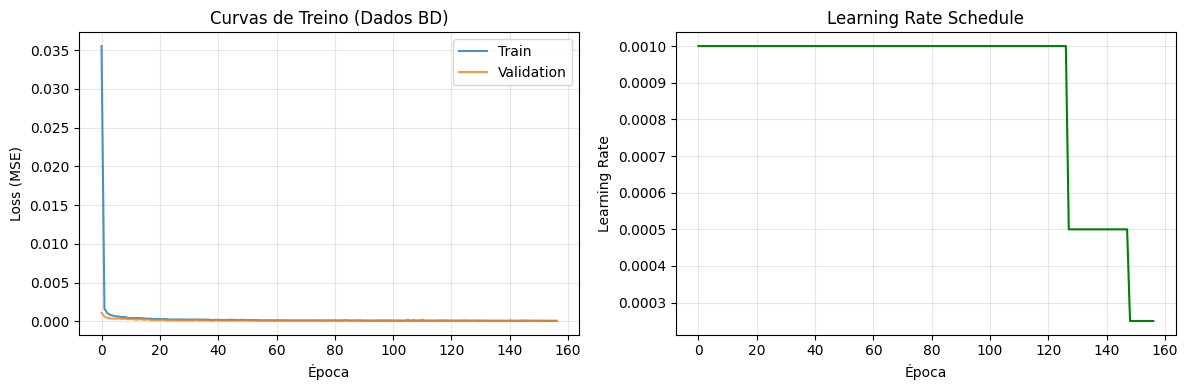

In [12]:
# Curvas de treino
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history['train_loss'], label='Train', alpha=0.8)
ax1.plot(history['val_loss'], label='Validation', alpha=0.8)
ax1.set_xlabel('Época')
ax1.set_ylabel('Loss (MSE)')
ax1.set_title('Curvas de Treino (Dados BD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['lr'], color='green')
ax2.set_xlabel('Época')
ax2.set_ylabel('Learning Rate')
ax2.set_title('Learning Rate Schedule')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Avaliação

In [13]:
# Carregar melhor modelo
model.load_state_dict(best_model_state)
model.eval()

# Predições no teste
X_test_tensor = torch.tensor(X_test, dtype=torch.float32).to(DEVICE)
with torch.no_grad():
    y_pred_norm = model(X_test_tensor).cpu().numpy()

# Desnormalizar
y_pred = y_pred_norm.copy()
y_pred[:, 0] = y_pred_norm[:, 0] * 12.0   # Ajuste fotoperíodo
y_pred[:, 1] = y_pred_norm[:, 1] * 100.0  # TPA %
y_pred[:, 2] = y_pred_norm[:, 2] * 100.0  # Alimentação %

y_true = y_test.copy()
y_true[:, 0] = y_test[:, 0] * 12.0
y_true[:, 1] = y_test[:, 1] * 100.0
y_true[:, 2] = y_test[:, 2] * 100.0

# Métricas
from sklearn.metrics import mean_absolute_error, r2_score

print("=" * 50)
print("MÉTRICAS NO TEST SET (Dados BD)")
print("=" * 50)

labels = ['Ajuste Fotoperíodo (h)', 'TPA (%)', 'Alimentação (%)']
for i, label in enumerate(labels):
    mae = mean_absolute_error(y_true[:, i], y_pred[:, i])
    r2 = r2_score(y_true[:, i], y_pred[:, i])
    print(f"\n{label}:")
    print(f"  MAE: {mae:.2f}")
    print(f"  R²:  {r2:.4f}")

MÉTRICAS NO TEST SET (Dados BD)

Ajuste Fotoperíodo (h):
  MAE: 0.01
  R²:  0.9938

TPA (%):
  MAE: 0.21
  R²:  0.9905

Alimentação (%):
  MAE: 0.12
  R²:  0.9770


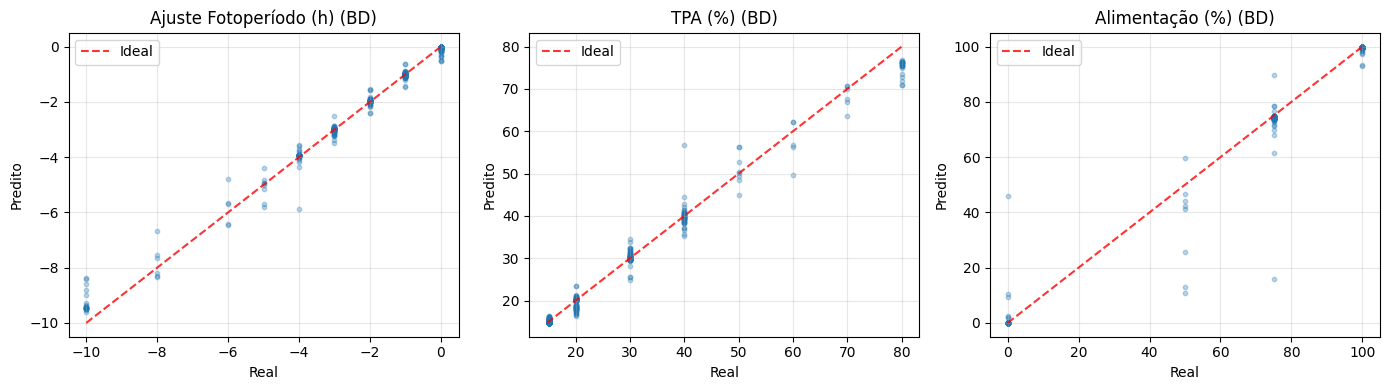

In [14]:
# Scatter plots
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for i, (ax, label) in enumerate(zip(axes, labels)):
    ax.scatter(y_true[:, i], y_pred[:, i], alpha=0.3, s=10)
    
    # Linha ideal
    lims = [min(y_true[:, i].min(), y_pred[:, i].min()),
            max(y_true[:, i].max(), y_pred[:, i].max())]
    ax.plot(lims, lims, 'r--', alpha=0.8, label='Ideal')
    
    ax.set_xlabel('Real')
    ax.set_ylabel('Predito')
    ax.set_title(f'{label} (BD)')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Análise Temporal

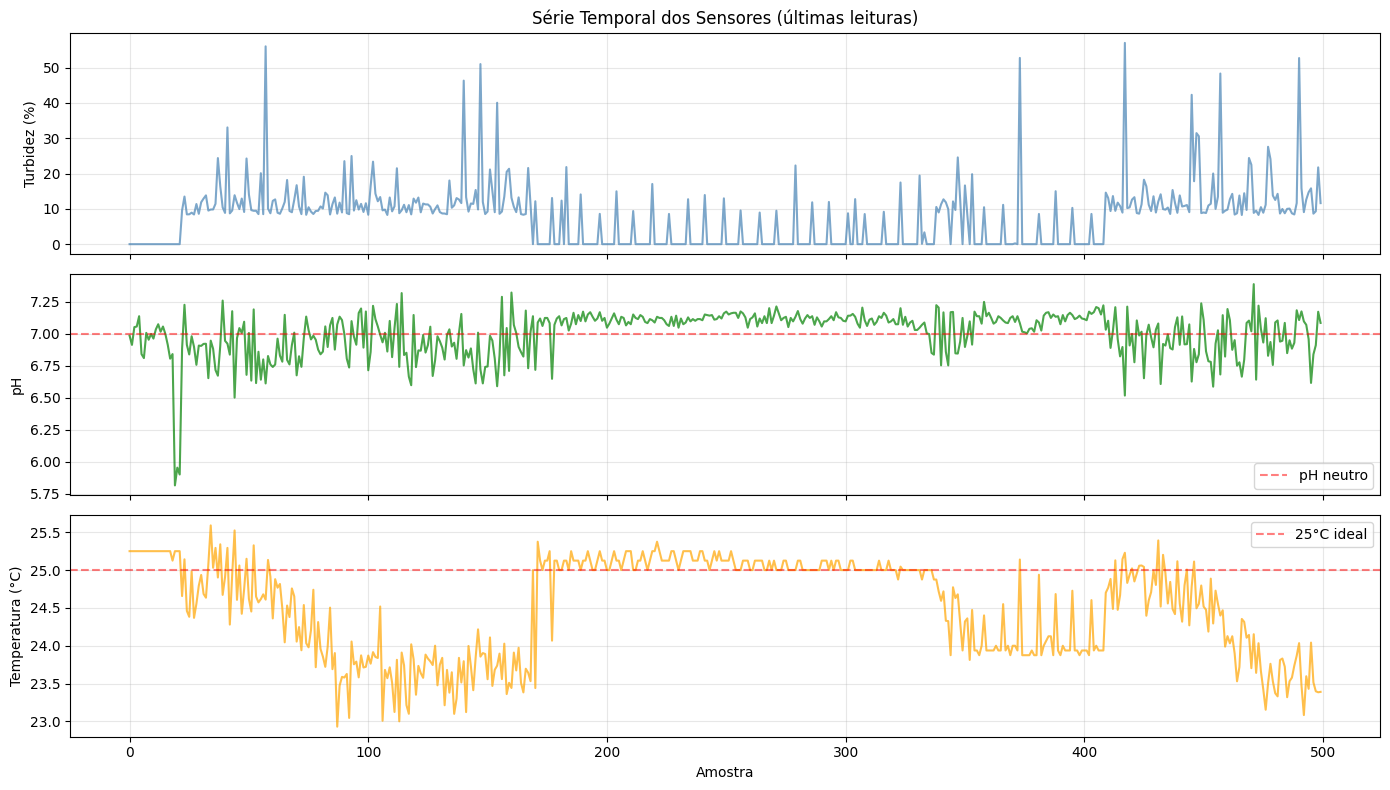

In [15]:
# Visualizar série temporal dos dados
# (primeiras 500 amostras para visualização)
n_plot = min(500, len(turbidity))

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

axes[0].plot(turbidity[:n_plot], color='steelblue', alpha=0.7)
axes[0].set_ylabel('Turbidez (%)')
axes[0].set_title('Série Temporal dos Sensores (últimas leituras)')
axes[0].grid(True, alpha=0.3)

axes[1].plot(ph[:n_plot], color='green', alpha=0.7)
axes[1].set_ylabel('pH')
axes[1].axhline(7.0, color='red', linestyle='--', alpha=0.5, label='pH neutro')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(temperature[:n_plot], color='orange', alpha=0.7)
axes[2].set_ylabel('Temperatura (°C)')
axes[2].set_xlabel('Amostra')
axes[2].axhline(25, color='red', linestyle='--', alpha=0.5, label='25°C ideal')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 9. Guardar Modelo

In [16]:
# Guardar modelo
torch.save(model.state_dict(), MODEL_PATH)
print(f"✓ Modelo guardado: {MODEL_PATH}")

# Guardar métricas
import json

metrics = {
    'source': 'database',
    'n_samples': n_samples,
    'epochs_trained': len(history['train_loss']),
    'best_val_loss': float(best_val_loss),
    'test_metrics': {
        'photoperiod_mae': float(mean_absolute_error(y_true[:, 0], y_pred[:, 0])),
        'tpa_mae': float(mean_absolute_error(y_true[:, 1], y_pred[:, 1])),
        'feeding_mae': float(mean_absolute_error(y_true[:, 2], y_pred[:, 2])),
    }
}

with open(METRICS_PATH, 'w') as f:
    json.dump(metrics, f, indent=2)
print(f"✓ Métricas guardadas: {METRICS_PATH}")

✓ Modelo guardado: C:\Projetos IADE\AquaSense\esp32-dashboard\ai\models\photoperiod_model.pt
✓ Métricas guardadas: C:\Projetos IADE\AquaSense\esp32-dashboard\ai\models\metrics.json


## 10. Teste de Inferência

In [17]:
def predict(turbidity, ph, temperature):
    """Faz predição com o modelo treinado."""
    # Normalizar input
    X = np.array([[turbidity, ph, temperature]], dtype=np.float32)
    X_norm = scaler.transform(X)
    
    # Predição
    model.eval()
    with torch.no_grad():
        X_tensor = torch.tensor(X_norm, dtype=torch.float32).to(DEVICE)
        y_pred = model(X_tensor).cpu().numpy()[0]
    
    # Desnormalizar
    adjustment = y_pred[0] * 12.0
    tpa = y_pred[1] * 100.0
    feeding = y_pred[2] * 100.0
    
    return adjustment, tpa, feeding

# Testes com valores típicos da BD
test_cases = [
    (5, 7.0, 25),    # Normal
    (15, 7.1, 25.5), # Ligeira turbidez
    (30, 6.8, 26),   # Turbidez moderada
    (50, 7.2, 24),   # Turbidez alta
    (80, 7.0, 25),   # Turbidez muito alta
]

print("Testes de Inferência (modelo treinado com dados BD):")
print("-" * 70)
for turb, ph_val, temp in test_cases:
    adj, tpa, feed = predict(turb, ph_val, temp)
    print(f"Turbidez={turb:3}%, pH={ph_val:.1f}, Temp={temp}°C → "
          f"Ajuste={adj:+.1f}h, TPA={tpa:.0f}%, Feed={feed:.0f}%")

Testes de Inferência (modelo treinado com dados BD):
----------------------------------------------------------------------
Turbidez=  5%, pH=7.0, Temp=25°C → Ajuste=-0.0h, TPA=15%, Feed=100%
Turbidez= 15%, pH=7.1, Temp=25.5°C → Ajuste=-0.0h, TPA=15%, Feed=100%
Turbidez= 30%, pH=6.8, Temp=26°C → Ajuste=-1.5h, TPA=20%, Feed=100%
Turbidez= 50%, pH=7.2, Temp=24°C → Ajuste=-3.2h, TPA=33%, Feed=74%
Turbidez= 80%, pH=7.0, Temp=25°C → Ajuste=-7.0h, TPA=65%, Feed=1%


## 11. Comparação com Regras Baseline

In [18]:
print("Comparação: Modelo vs Regras Baseline")
print("=" * 70)

for turb, ph_val, temp in test_cases:
    # Modelo
    adj_model, tpa_model, feed_model = predict(turb, ph_val, temp)
    
    # Baseline (regras)
    adj_rule = get_expected_adjustment(turb, ph=ph_val, temperature=temp)
    tpa_rule = get_expected_tpa(turb, ph=ph_val, temperature=temp)
    feed_rule = get_expected_feeding(turb, ph=ph_val, temperature=temp)
    
    print(f"\nInput: Turb={turb}%, pH={ph_val}, Temp={temp}°C")
    print(f"  Modelo:  Adj={adj_model:+.1f}h, TPA={tpa_model:.0f}%, Feed={feed_model:.0f}%")
    print(f"  Regras:  Adj={adj_rule:+.1f}h, TPA={tpa_rule:.0f}%, Feed={feed_rule:.0f}%")

Comparação: Modelo vs Regras Baseline

Input: Turb=5%, pH=7.0, Temp=25°C
  Modelo:  Adj=-0.0h, TPA=15%, Feed=100%
  Regras:  Adj=+0.0h, TPA=15%, Feed=100%

Input: Turb=15%, pH=7.1, Temp=25.5°C
  Modelo:  Adj=-0.0h, TPA=15%, Feed=100%
  Regras:  Adj=+0.0h, TPA=15%, Feed=100%

Input: Turb=30%, pH=6.8, Temp=26°C
  Modelo:  Adj=-1.5h, TPA=20%, Feed=100%
  Regras:  Adj=-1.0h, TPA=20%, Feed=100%

Input: Turb=50%, pH=7.2, Temp=24°C
  Modelo:  Adj=-3.2h, TPA=33%, Feed=74%
  Regras:  Adj=-3.0h, TPA=30%, Feed=75%

Input: Turb=80%, pH=7.0, Temp=25°C
  Modelo:  Adj=-7.0h, TPA=65%, Feed=1%
  Regras:  Adj=-6.0h, TPA=60%, Feed=0%
